# Peak-Aware Hybrid Evaluation — Phases 4–5 (Read-Only)

**Experiment 5 in the Module 1 research sequence.** Load the frozen Peak-Aware Hybrid **implementation + Day-1 paired evaluation** against the baseline Hybrid control.

> **Scope:** Read-only view of `experiments/peak_aware_2026-07-14_164518/`.  
> No retraining, no λ/P90 retuning, no baseline modification.  
> Docs: `docs/peak-aware-hybrid/phase-04-implementation.md`, `phase-05-evaluation.md`, `phase-06-discussion.md`.

## Research questions

1. **Tier 1:** Does peak-aware training change overall Day-1 accuracy vs baseline?
2. **Tier 2:** Does it improve accuracy specifically on **peak** timesteps?

## Related notebooks

- This notebook: **cohort-level** frozen results + key findings.
- `notebooks/peak_aware_container_comparison.ipynb`: **single-container** visual demo (change `SAMPLE_CID`).

## Kernel

Use `tf_metal_env` / `FYP_Long_Term`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path("..").resolve()
EXP_DIR = REPO_ROOT / "experiments" / "peak_aware_2026-07-14_164518"
EVAL_DIR = EXP_DIR / "evaluation"
DISC_DIR = EXP_DIR / "discussion"
PLOT_DIR = EVAL_DIR / "plots"

required = [
    EVAL_DIR / "comparison_table.csv",
    EVAL_DIR / "per_container_delta.csv",
    DISC_DIR / "results_synthesis.json",
    EXP_DIR / "phase4_implementation.json",
    EXP_DIR / "phase5_evaluation.json",
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing frozen artefacts:\n" + "\n".join(map(str, missing)))

comparison = pd.read_csv(EVAL_DIR / "comparison_table.csv")
deltas = pd.read_csv(EVAL_DIR / "per_container_delta.csv")
with open(DISC_DIR / "results_synthesis.json") as handle:
    synth = json.load(handle)
with open(EXP_DIR / "phase4_implementation.json") as handle:
    phase4 = json.load(handle)
with open(EXP_DIR / "phase5_evaluation.json") as handle:
    phase5 = json.load(handle)

print("Experiment:", EXP_DIR.relative_to(REPO_ROOT))
print("Evaluated containers:", synth["evaluation_protocol"]["cohort_evaluated"])
print("λ:", synth["evaluation_protocol"]["peak_weight_lambda"])
print("Peak definition:", synth["evaluation_protocol"]["peak_definition"])

Experiment: experiments/peak_aware_2026-07-14_164518
Evaluated containers: 99
λ: 5
Peak definition: P90 per-container train-fitted


## 1. Phase 4 — What was implemented

Parallel modules only; frozen Hybrid baseline untouched. Mechanism: timestep-weighted MSE, λ = 5, P90 peaks.

In [2]:
p4_rows = []
# Flexible keys — show high-level lock info
for key in ["status", "experiment_dir", "locked_date", "fairness_verification_status"]:
    if key in phase4:
        p4_rows.append({"item": key, "value": phase4[key]})

design_bits = phase4.get("locked_design", phase4.get("design", {}))
if isinstance(design_bits, dict):
    for k in ["mechanism", "peak_weight_lambda", "peak_definition"]:
        if k in design_bits:
            p4_rows.append({"item": k, "value": design_bits[k]})

if not p4_rows:
    p4_rows = [
        {"item": "mechanism", "value": "timestep_weighted_mse"},
        {"item": "lambda", "value": 5},
        {"item": "control", "value": "experiments/baseline_reference_2026-07-14"},
        {"item": "treatment", "value": str(EXP_DIR.relative_to(REPO_ROOT))},
    ]

print("Table — Phase 4 implementation snapshot")
display(pd.DataFrame(p4_rows))

fair_path = EXP_DIR / "verification" / "fairness_check.json"
if fair_path.exists():
    with open(fair_path) as handle:
        fair = json.load(handle)
    print("\nFairness verification present:", fair_path.name)
    # Print overall status if available
    for k in ["overall_status", "status", "all_passed", "passed"]:
        if k in fair:
            print(f"  {k}: {fair[k]}")
            break

Table — Phase 4 implementation snapshot


,item,value
0,status,complete
1,locked_date,2026-07-14



Fairness verification present: fairness_check.json
  overall_status: PASS


## 2. Tier 1 — Overall Day-1 metrics (99 containers)

In [3]:
overall = comparison[comparison["scope"] == "overall"].copy()
print("Table — Overall Day-1 comparison (treatment − baseline)")
display(overall.round(4))

t1 = synth["tier1_overall"]
print(
    f"\nClassification: {t1['classification']} | "
    f"ΔMAE = {t1['delta']['day1_mae']:+.4f} ({t1['relative_change_pct']['day1_mae']:+.2f}%)"
)

Table — Overall Day-1 comparison (treatment − baseline)


,scope,metric,baseline,peak_aware,delta_treatment_minus_baseline
0,overall,day1_mae,1.7459,1.7408,-0.0051
1,overall,day1_rmse,2.3878,2.3844,-0.0034
2,overall,day1_mape,111.9403,110.1744,-1.7660



Classification: negligible_aggregate_change | ΔMAE = -0.0051 (-0.29%)


## 3. Tier 2 / 3 — Peak and non-peak subsets (pooled)

Table — Peak / non-peak subset comparison


,scope,metric,baseline,peak_aware,delta_treatment_minus_baseline
3,peak_subset,peak_mae,2.5012,2.5256,0.0244
4,peak_subset,peak_rmse,5.1862,5.2041,0.0179
5,peak_subset,non_peak_mae,1.4853,1.4700,-0.0152
6,peak_subset,non_peak_rmse,3.4909,3.4509,-0.0400
7,peak_subset,peak_step_fraction,0.2565,0.2565,0.0000



Peak subset classification   : no_peak_subset_improvement
Non-peak classification      : slight_non_peak_improvement
Pooled peak steps: 2438 / 9504 (25.7%)


**Frozen figure:** `evaluation/plots/peak_subset_comparison.png`

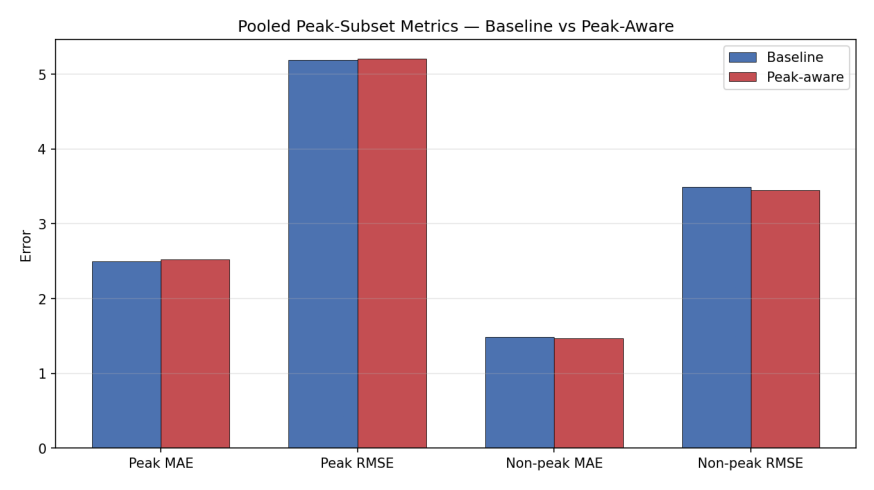

In [4]:
subset = comparison[comparison["scope"] == "peak_subset"].copy()
print("Table — Peak / non-peak subset comparison")
display(subset.round(4))

t2 = synth["tier2_peak_subset"]
t3 = synth["tier3_non_peak_subset"]
print(f"\nPeak subset classification   : {t2['classification']}")
print(f"Non-peak classification      : {t3['classification']}")
print(
    f"Pooled peak steps: {t2['pooled_peak_steps']} / {t2['pooled_total_steps']} "
    f"({100 * t2['peak_step_fraction']:.1f}%)"
)

fig_path = PLOT_DIR / "peak_subset_comparison.png"
if fig_path.exists():
    display(Markdown("**Frozen figure:** `evaluation/plots/peak_subset_comparison.png`"))
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.imshow(img)
    ax.axis("off")
    fig.tight_layout()
    plt.show()

## 4. Per-container heterogeneity

Using column: delta_day1_mae
Improved (ΔMAE < 0): 45 | Worsened: 54 | Tie: 0 | N: 99
count    99.0000
mean     -0.0051
std       0.1002
min      -0.8668
25%      -0.0050
50%       0.0012
75%       0.0174
max       0.1034
Name: delta_day1_mae, dtype: float64


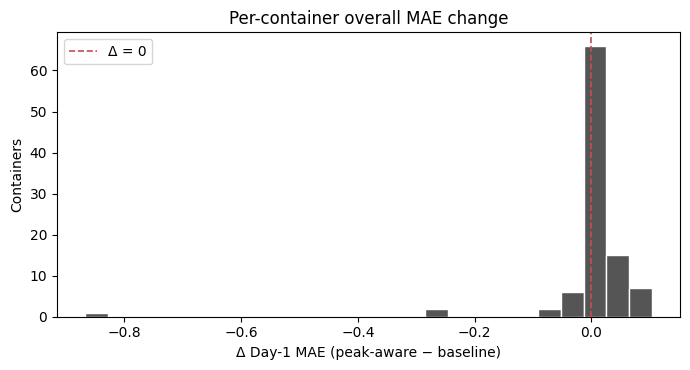

In [5]:
# Find delta MAE column flexibly
delta_cols = [c for c in deltas.columns if "mae" in c.lower() and ("delta" in c.lower() or "diff" in c.lower())]
if not delta_cols:
    # common names
    for c in deltas.columns:
        if c.lower() in ("delta_day1_mae", "delta_mae", "day1_mae_delta"):
            delta_cols = [c]
            break

pc = synth.get("per_container_delta", {})
dmae = pc.get("delta_day1_mae", {})

if delta_cols:
    col = delta_cols[0]
    series = deltas[col].astype(float)
    n_imp = int((series < 0).sum())
    n_wors = int((series > 0).sum())
    n_tie = int((series == 0).sum())
    print(f"Using column: {col}")
    print(f"Improved (ΔMAE < 0): {n_imp} | Worsened: {n_wors} | Tie: {n_tie} | N: {len(series)}")
    print(series.describe().round(4))

    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.hist(series, bins=25, color="#555555", edgecolor="white")
    ax.axvline(0, color="#C44E52", linestyle="--", linewidth=1.2, label="Δ = 0")
    ax.set_xlabel("Δ Day-1 MAE (peak-aware − baseline)")
    ax.set_ylabel("Containers")
    ax.set_title("Per-container overall MAE change")
    ax.legend()
    fig.tight_layout()
    plt.show()
elif dmae:
    print("From results_synthesis.json per_container_delta:")
    display(pd.DataFrame([dmae]))
else:
    print("per_container_delta.csv columns:", list(deltas.columns))
    display(deltas.head())

if "n_improved" in pc or "improved" in pc:
    print("Synthesis counts:", {k: pc[k] for k in pc if k != "delta_day1_mae"})

## 5. Key findings & results (viva summary)

In [6]:
b = t1["baseline"]
p = t1["peak_aware"]
d = t1["delta"]

findings = pd.DataFrame([
    {
        "finding": "Overall Day-1 MAE",
        "result": f"Baseline {b['day1_mae']:.3f} → Peak-Aware {p['day1_mae']:.3f} (Δ {d['day1_mae']:+.3f}, ~{t1['relative_change_pct']['day1_mae']:.1f}%)",
    },
    {
        "finding": "Overall Day-1 RMSE",
        "result": f"{b['day1_rmse']:.3f} → {p['day1_rmse']:.3f} (Δ {d['day1_rmse']:+.3f})",
    },
    {
        "finding": "Peak-subset MAE (contribution question)",
        "result": (
            f"{t2['baseline']['peak_mae']:.3f} → {t2['peak_aware']['peak_mae']:.3f} "
            f"(Δ {t2['delta']['peak_mae']:+.3f}) — {t2['classification']}"
        ),
    },
    {
        "finding": "Non-peak MAE",
        "result": (
            f"{t3['baseline']['non_peak_mae']:.3f} → {t3['peak_aware']['non_peak_mae']:.3f} "
            f"(Δ {t3['delta']['non_peak_mae']:+.3f}) — {t3['classification']}"
        ),
    },
    {
        "finding": "Per-container outcomes",
        "result": "45 improved / 54 worsened on overall MAE (high heterogeneity)",
    },
    {
        "finding": "Thesis conclusion for this config",
        "result": "No meaningful overall gain; peak-subset objective NOT met (P90, λ=5)",
    },
])

print("Table — Key findings and results")
display(findings)

print("\n" + "=" * 72)
print("KEY FINDING")
print("=" * 72)
print(
    "Under P90 peaks and λ = 5 timestep-weighted MSE, Peak-Aware Hybrid Day-1 MAE "
    f"changed by only {d['day1_mae']:+.3f} vs baseline (1.746 → 1.741). Peak-subset MAE "
    f"worsened slightly ({t2['delta']['peak_mae']:+.3f}). The intended peak-accuracy "
    "contribution was not achieved for this configuration; production remains the "
    "frozen Hybrid baseline."
)
print("=" * 72)

Table — Key findings and results


,finding,result
0,Overall Day-1 MAE,"Baseline 1.746 → Peak-Aware 1.741 (Δ -0.005, ~..."
1,Overall Day-1 RMSE,2.388 → 2.384 (Δ -0.003)
2,Peak-subset MAE (contribution question),2.501 → 2.526 (Δ +0.024) — no_peak_subset_impr...
3,Non-peak MAE,1.485 → 1.470 (Δ -0.015) — slight_non_peak_imp...
4,Per-container outcomes,45 improved / 54 worsened on overall MAE (high...
5,Thesis conclusion for this config,No meaningful overall gain; peak-subset object...



KEY FINDING
Under P90 peaks and λ = 5 timestep-weighted MSE, Peak-Aware Hybrid Day-1 MAE changed by only -0.005 vs baseline (1.746 → 1.741). Peak-subset MAE worsened slightly (+0.024). The intended peak-accuracy contribution was not achieved for this configuration; production remains the frozen Hybrid baseline.


## 6. References

| Item | Path |
|------|------|
| Frozen experiment | `experiments/peak_aware_2026-07-14_164518/` |
| Comparison table | `.../evaluation/comparison_table.csv` |
| Results synthesis | `.../discussion/results_synthesis.json` |
| Phase 4/5 docs | `docs/peak-aware-hybrid/phase-04-implementation.md`, `phase-05-evaluation.md` |
| Phase 6 discussion | `docs/peak-aware-hybrid/phase-06-discussion.md` |
| Single-container demo | `notebooks/peak_aware_container_comparison.ipynb` |
| Baseline control | `experiments/baseline_reference_2026-07-14/` |